In [1]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [4]:
gender_map = {'F': 0, 'M': 1}
class_labels = ['N', 'P', 'Y']
test_df = pd.read_csv("../diabetes_test_normalized.csv")
test_df['gender'] = test_df['gender'].map(gender_map)

X_test = test_df.drop(columns=['class'])
y_test = test_df['class']
print("Test set loaded. Shape:", X_test.shape)

Test set loaded. Shape: (166, 11)


In [5]:
full_norm = pd.read_csv("../diabetes_milestone1_normalized.csv")
full_norm['gender'] = full_norm['gender'].map(gender_map)
# Isolate the 80% training set (pre-SMOTE)
X_f = full_norm.drop(columns=['class'])
y_f = full_norm['class']
X_train_base, _, y_train_base, _ = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

In [6]:
gnb_base = GaussianNB()
gnb_base.fit(X_train_base, y_train_base)
y_pred_base = gnb_base.predict(X_test)

In [7]:
print("--- MODEL 1: BASELINE (IMBALANCED) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=class_labels))

--- MODEL 1: BASELINE (IMBALANCED) ---
Accuracy: 0.9337

Classification Report:
              precision    recall  f1-score   support

           N       0.87      0.68      0.76        19
           P       0.83      0.62      0.71         8
           Y       0.94      0.99      0.96       139

    accuracy                           0.93       166
   macro avg       0.88      0.76      0.81       166
weighted avg       0.93      0.93      0.93       166



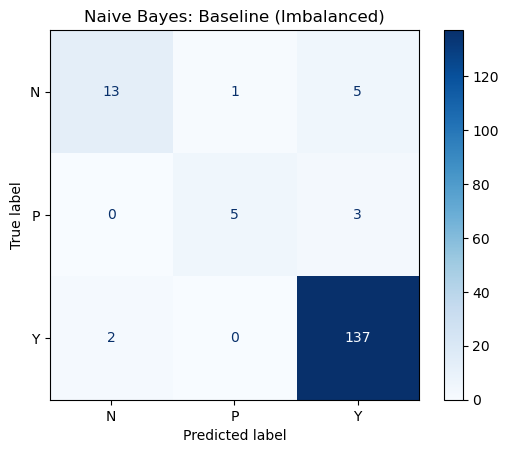

In [8]:
cm_base = confusion_matrix(y_test, y_pred_base)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=class_labels)
disp_base.plot(cmap="Blues")
plt.title("Naive Bayes: Baseline (Imbalanced)")
plt.show()

In [9]:
train_smote = pd.read_csv("../diabetes_train_smote_normalized.csv")
train_smote['gender'] = train_smote['gender'].map(gender_map)

X_train_smote = train_smote.drop(columns=['class'])
y_train_smote = train_smote['class']

In [10]:
gnb_smote = GaussianNB()
gnb_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = gnb_smote.predict(X_test)

In [11]:
print("--- MODEL 2: SMOTE (BALANCED) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote, target_names=class_labels))

--- MODEL 2: SMOTE (BALANCED) ---
Accuracy: 0.9458

Classification Report:
              precision    recall  f1-score   support

           N       0.87      0.68      0.76        19
           P       1.00      0.88      0.93         8
           Y       0.95      0.99      0.97       139

    accuracy                           0.95       166
   macro avg       0.94      0.85      0.89       166
weighted avg       0.94      0.95      0.94       166



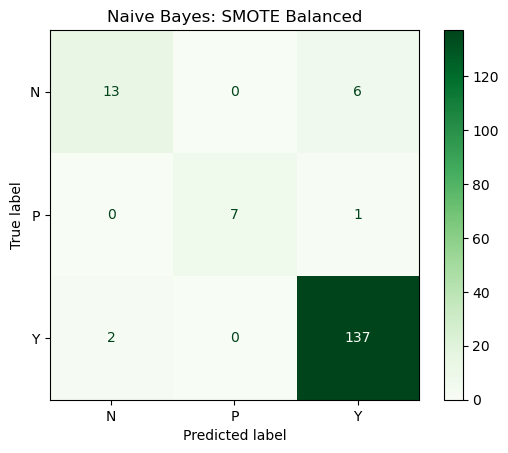

In [12]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=class_labels)
disp_smote.plot(cmap="Greens")
plt.title("Naive Bayes: SMOTE Balanced")
plt.show()

In [13]:
train_smt = pd.read_csv("../diabetes_train_smotetomek_normalized.csv")
train_smt['gender'] = train_smt['gender'].map(gender_map)

X_train_smt = train_smt.drop(columns=['class'])
y_train_smt = train_smt['class']

In [14]:
gnb_smt = GaussianNB()
gnb_smt.fit(X_train_smt, y_train_smt)
y_pred_smt = gnb_smt.predict(X_test)

In [15]:
print("--- MODEL 3: SMOTETOMEK (CLEANED) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smt, target_names=class_labels))


--- MODEL 3: SMOTETOMEK (CLEANED) ---
Accuracy: 0.9458

Classification Report:
              precision    recall  f1-score   support

           N       0.87      0.68      0.76        19
           P       1.00      0.88      0.93         8
           Y       0.95      0.99      0.97       139

    accuracy                           0.95       166
   macro avg       0.94      0.85      0.89       166
weighted avg       0.94      0.95      0.94       166



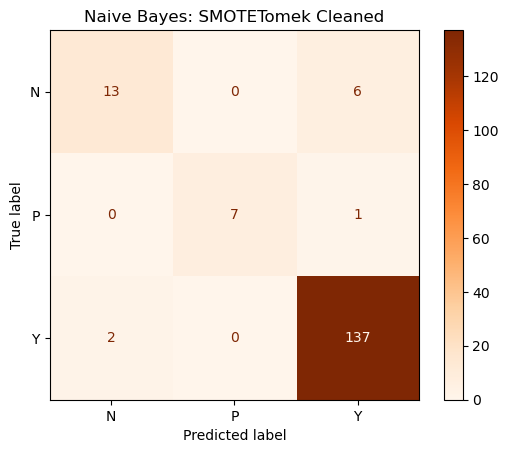

In [16]:
cm_smt = confusion_matrix(y_test, y_pred_smt)
disp_smt = ConfusionMatrixDisplay(confusion_matrix=cm_smt, display_labels=class_labels)
disp_smt.plot(cmap="Oranges")
plt.title("Naive Bayes: SMOTETomek Cleaned")
plt.show()

In [18]:
# ── FINAL COMPARISON ──────────────────────────────────────────────────────
comparison_data = {
    "Model": ["Baseline (Imbalanced)", "SMOTE", "SMOTETomek"],
    "Accuracy Score": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_smt)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("--- FINAL ACCURACY COMPARISON ---")
print(comparison_df)



--- FINAL ACCURACY COMPARISON ---
                   Model  Accuracy Score
0  Baseline (Imbalanced)        0.933735
1                  SMOTE        0.945783
2             SMOTETomek        0.945783
